# Function Transformer

## Objective

The Function Transformer is used to apply a mathematical function to a feature. It is particularly useful when the data is highly skewed and does not follow a normal distribution.

In this experiment, we apply a logarithmic transformation to the **Population** feature from the California Housing dataset using Scikit-Learn's `FunctionTransformer`.

---

## Why Use Function Transformer?

Many Machine Learning algorithms perform better when numerical features are approximately normally distributed.

Highly skewed features can:

- Affect model performance
- Increase variance
- Make patterns harder to learn

Applying a logarithmic transformation helps:

- Reduce skewness
- Compress large values
- Improve feature distribution

---

## Dataset

**California Housing Dataset**

Selected Feature:

- Population

The Population feature is positively skewed because some regions have significantly larger populations than others.

---

## Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import FunctionTransformer

In [2]:
df = pd.read_csv("fetch_california_housing.csv")
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [3]:
print("Original Skewness:", df["Population"].skew())

Original Skewness: 4.93585822672712


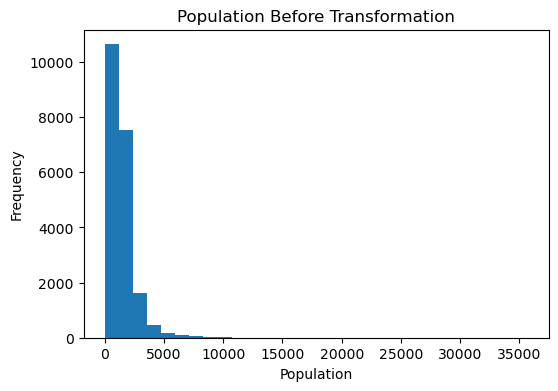

In [4]:
plt.figure(figsize=(6,4))
plt.hist(df["Population"], bins=30)
plt.title("Population Before Transformation")
plt.xlabel("Population")
plt.ylabel("Frequency")
plt.show()

In [5]:
transformer = FunctionTransformer(np.log1p)

df["Population_Log"] = transformer.fit_transform(
    df[["Population"]]
)

In [6]:
print("Transformed Skewness:", df["Population_Log"].skew())

Transformed Skewness: -1.0440866961519721


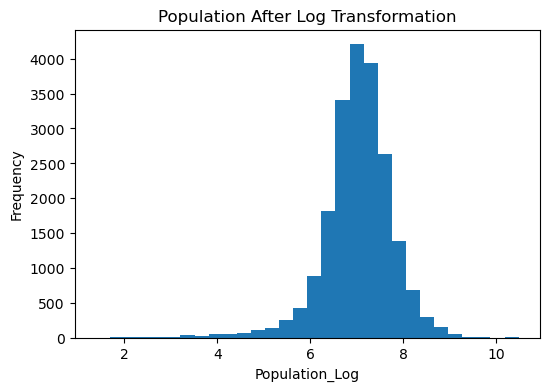

In [7]:
plt.figure(figsize=(6,4))
plt.hist(df["Population_Log"], bins=30)
plt.title("Population After Log Transformation")
plt.xlabel("Population_Log")
plt.ylabel("Frequency")
plt.show()

In [8]:
import scipy.stats as stats
import matplotlib.pyplot as plt

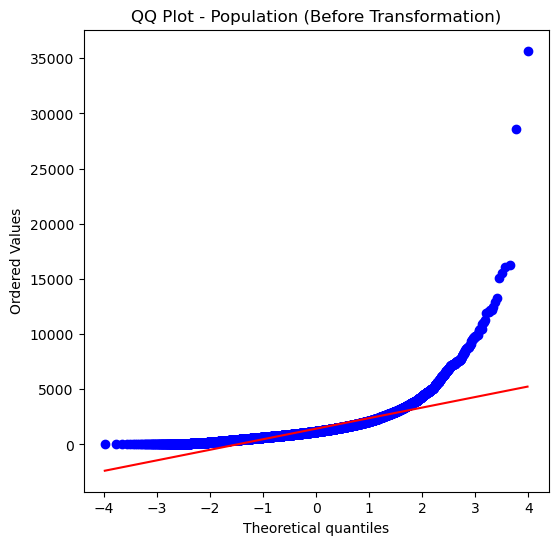

In [9]:
plt.figure(figsize=(6,6))

stats.probplot(df["Population"], dist="norm", plot=plt)

plt.title("QQ Plot - Population (Before Transformation)")
plt.show()

4.93585822672712


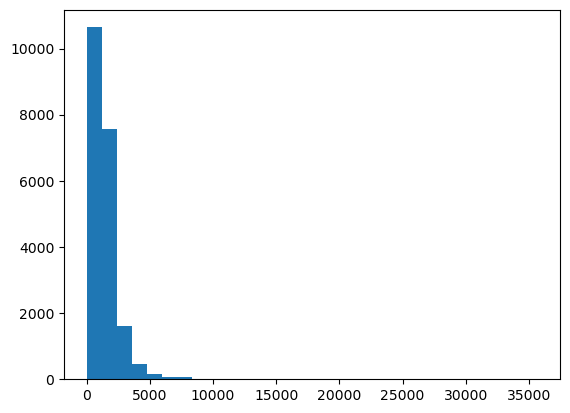

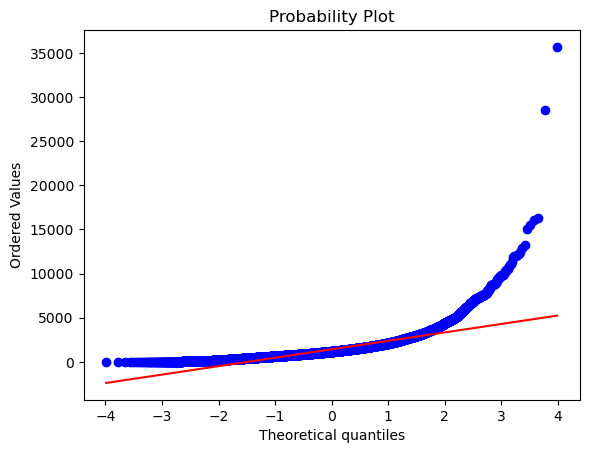

-1.0440866961519721


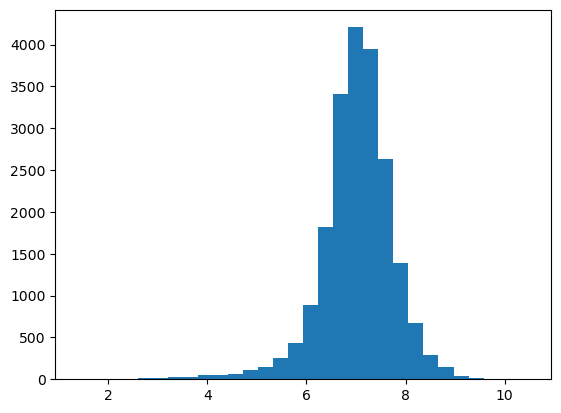

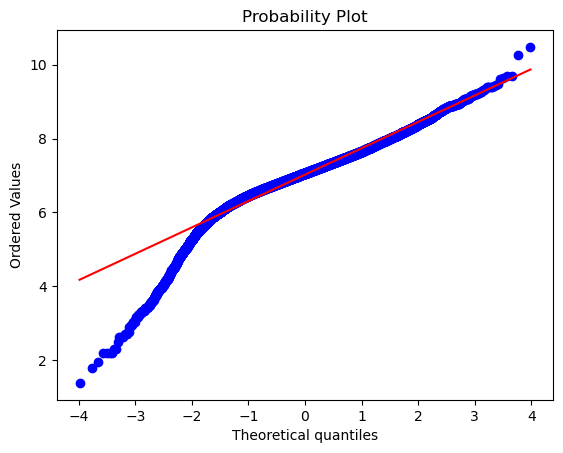

In [10]:
# 1. Check skewness
print(df["Population"].skew())

# 2. Histogram
plt.hist(df["Population"], bins=30)
plt.show()

# 3. QQ Plot
stats.probplot(df["Population"], dist="norm", plot=plt)
plt.show()

# 4. Apply FunctionTransformer
from sklearn.preprocessing import FunctionTransformer
import numpy as np

ft = FunctionTransformer(np.log1p)

df["Population_log"] = ft.fit_transform(df[["Population"]])

# 5. Check skewness again
print(df["Population_log"].skew())

# 6. Histogram after transformation
plt.hist(df["Population_log"], bins=30)
plt.show()

# 7. QQ Plot after transformation
stats.probplot(df["Population_log"], dist="norm", plot=plt)
plt.show()

In [11]:
from sklearn.model_selection import train_test_split

X = df[['Population']]
y = df['MedHouseVal']   # Target column

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [12]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

model = LinearRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("R2 Score Before:", r2_score(y_test, y_pred))

R2 Score Before: 9.303316180342414e-05


In [13]:
from sklearn.preprocessing import FunctionTransformer
import numpy as np

ft = FunctionTransformer(np.log1p)

X_train_transformed = ft.fit_transform(X_train)
X_test_transformed = ft.transform(X_test)

In [14]:
model2 = LinearRegression()

model2.fit(X_train_transformed, y_train)

y_pred2 = model2.predict(X_test_transformed)

print("R2 Score After:", r2_score(y_test, y_pred2))

R2 Score After: -0.00015549404945480738


In [15]:
ft_log = FunctionTransformer(np.log1p)

df["Population_log"] = ft_log.fit_transform(
    df[["Population"]]
)

print(df["Population_log"].skew())

-1.0440866961519721


In [16]:
ft_sqrt = FunctionTransformer(np.sqrt)

df["Population_sqrt"] = ft_sqrt.fit_transform(
    df[["Population"]]
)

print(df["Population_sqrt"].skew())

1.2246549321367803


In [17]:
ft_cbrt = FunctionTransformer(np.cbrt)

df["Population_cbrt"] = ft_cbrt.fit_transform(
    df[["Population"]]
)

print(df["Population_cbrt"].skew())

0.5225871727774413


In [18]:
print("Original :", df["Population"].skew())
print("Log      :", df["Population_log"].skew())
print("Sqrt     :", df["Population_sqrt"].skew())
print("Cube Root:", df["Population_cbrt"].skew())

Original : 4.93585822672712
Log      : -1.0440866961519721
Sqrt     : 1.2246549321367803
Cube Root: 0.5225871727774413


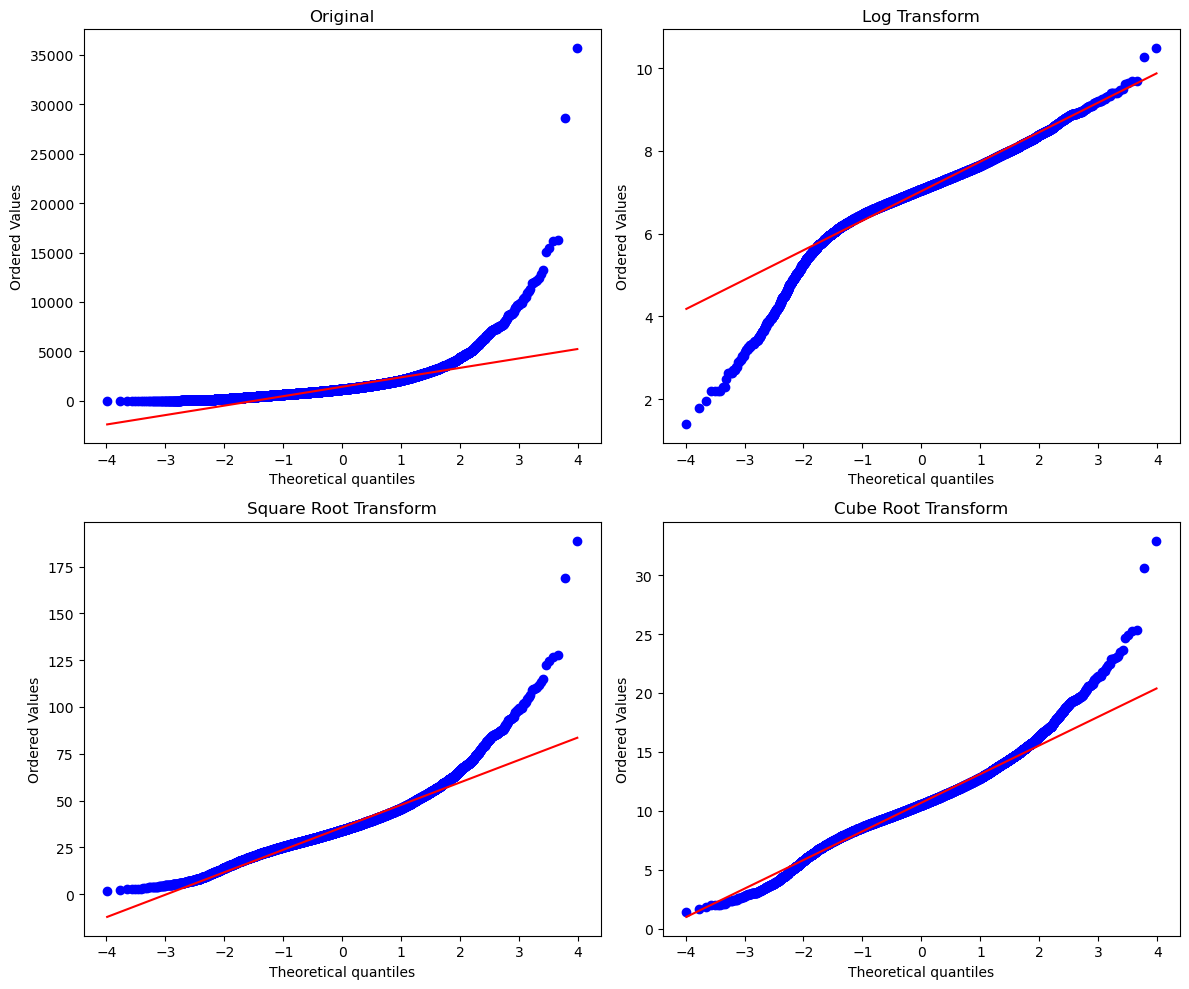

In [19]:
import scipy.stats as stats
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Original
stats.probplot(df["Population"], dist="norm", plot=axes[0,0])
axes[0,0].set_title("Original")

# Log Transform
stats.probplot(df["Population_log"], dist="norm", plot=axes[0,1])
axes[0,1].set_title("Log Transform")

# Square Root Transform
stats.probplot(df["Population_sqrt"], dist="norm", plot=axes[1,0])
axes[1,0].set_title("Square Root Transform")

# Cube Root Transform
stats.probplot(df["Population_cbrt"], dist="norm", plot=axes[1,1])
axes[1,1].set_title("Cube Root Transform")

plt.tight_layout()
plt.show()

# Power Transformer

## Objective

Power Transformation is a feature engineering technique used to make data more Gaussian (normally distributed). It helps reduce skewness, stabilize variance, and improve the performance of Machine Learning algorithms.

In this experiment, the `cnt` feature from the Bike Sharing Dataset is transformed using Scikit-Learn's `PowerTransformer`.

---

## Why Use Power Transformer?

Many Machine Learning algorithms assume that numerical features follow a normal distribution. Highly skewed features can negatively affect model performance.

Power Transformation helps by:

- Reducing skewness
- Making data more normally distributed
- Stabilizing variance
- Improving model performance

---

## Dataset

### Bike Sharing Dataset

Selected Feature:

- `cnt` (Total Count of Bike Rentals)

The `cnt` feature is positively skewed because bike rental counts vary significantly across different hours and conditions.

---

## Import Required Libraries

In [22]:
df2 = pd.read_csv("hour.csv")

In [23]:
print(df2["cnt"].skew())

1.2774116037490577


In [24]:
from sklearn.preprocessing import PowerTransformer

pt = PowerTransformer(method="yeo-johnson")

df2["cnt_pt"] = pt.fit_transform(df2[["cnt"]])

In [25]:
print(df2["cnt_pt"].skew())

-0.13739713587000427


((array([-3.94509974, -3.7271979 , -3.60788822, ...,  3.60788822,
          3.7271979 ,  3.94509974]),
  array([  1,   1,   1, ..., 970, 976, 977])),
 (np.float64(169.56208274455796),
  np.float64(189.4630876345015),
  np.float64(0.9346293252087196)))

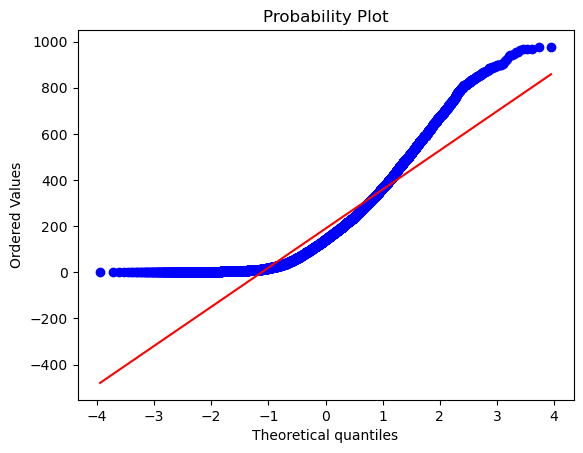

In [26]:
stats.probplot(df2["cnt"], dist="norm", plot=plt)

((array([-3.94509974, -3.7271979 , -3.60788822, ...,  3.60788822,
          3.7271979 ,  3.94509974]),
  array([-1.98301337, -1.98301337, -1.98301337, ...,  2.3134119 ,
          2.32269939,  2.32424338])),
 (np.float64(0.9888732152018866),
  np.float64(5.445466642575354e-16),
  np.float64(0.9886586533599137)))

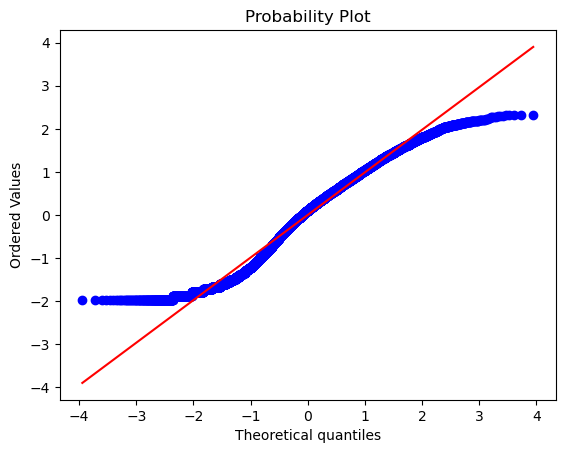

In [27]:
stats.probplot(df2["cnt_pt"], dist="norm", plot=plt)

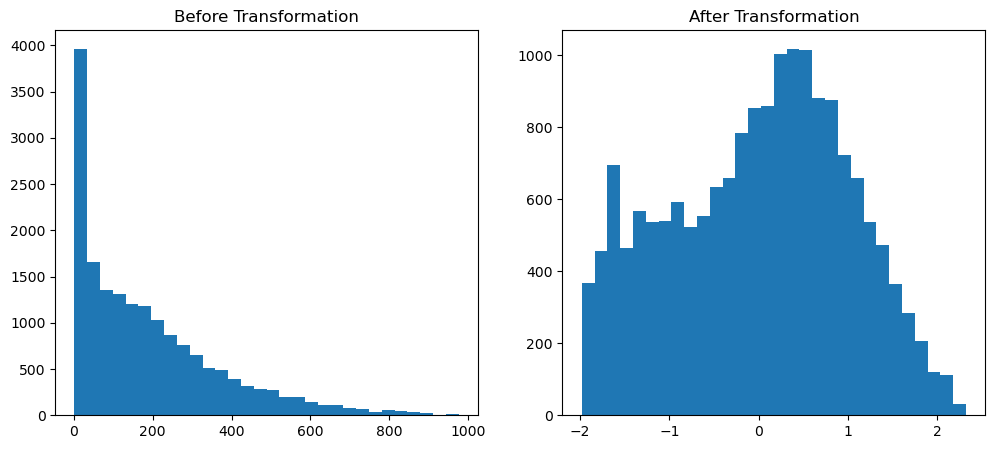

In [28]:
fig, ax = plt.subplots(1,2, figsize=(12,5))

ax[0].hist(df2["cnt"], bins=30)
ax[0].set_title("Before Transformation")

ax[1].hist(df2["cnt_pt"], bins=30)
ax[1].set_title("After Transformation")

plt.show()

In [29]:
comparison = pd.DataFrame({
    "Feature":["cnt","cnt_pt"],
    "Skewness":[
        df2["cnt"].skew(),
        df2["cnt_pt"].skew()
    ]
})

comparison

,Feature,Skewness
0,cnt,1.277412
1,cnt_pt,-0.137397


In [30]:
print(df2["cnt"].min())

1


In [31]:
from sklearn.preprocessing import PowerTransformer

pt_boxcox = PowerTransformer(method='box-cox')

df2["cnt_bc"] = pt_boxcox.fit_transform(
    df2[["cnt"]]
)

In [32]:
print("Original :", df2["cnt"].skew())
print("Yeo-Johnson :", df2["cnt_pt"].skew())
print("Box-Cox :", df2["cnt_bc"].skew())

Original : 1.2774116037490577
Yeo-Johnson : -0.13739713587000427
Box-Cox : -0.14792797141773945


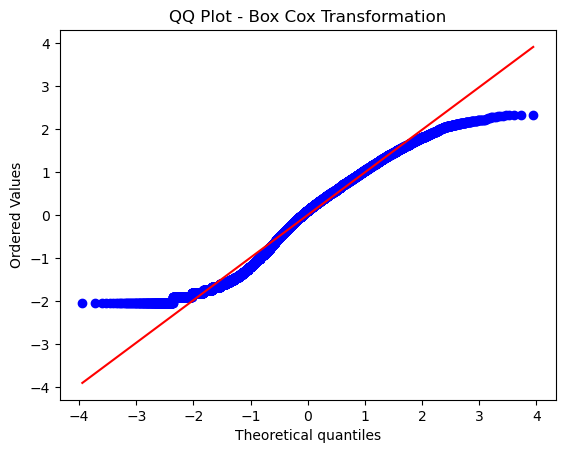

In [33]:
import scipy.stats as stats
import matplotlib.pyplot as plt

stats.probplot(df2["cnt_bc"], dist="norm", plot=plt)

plt.title("QQ Plot - Box Cox Transformation")
plt.show()

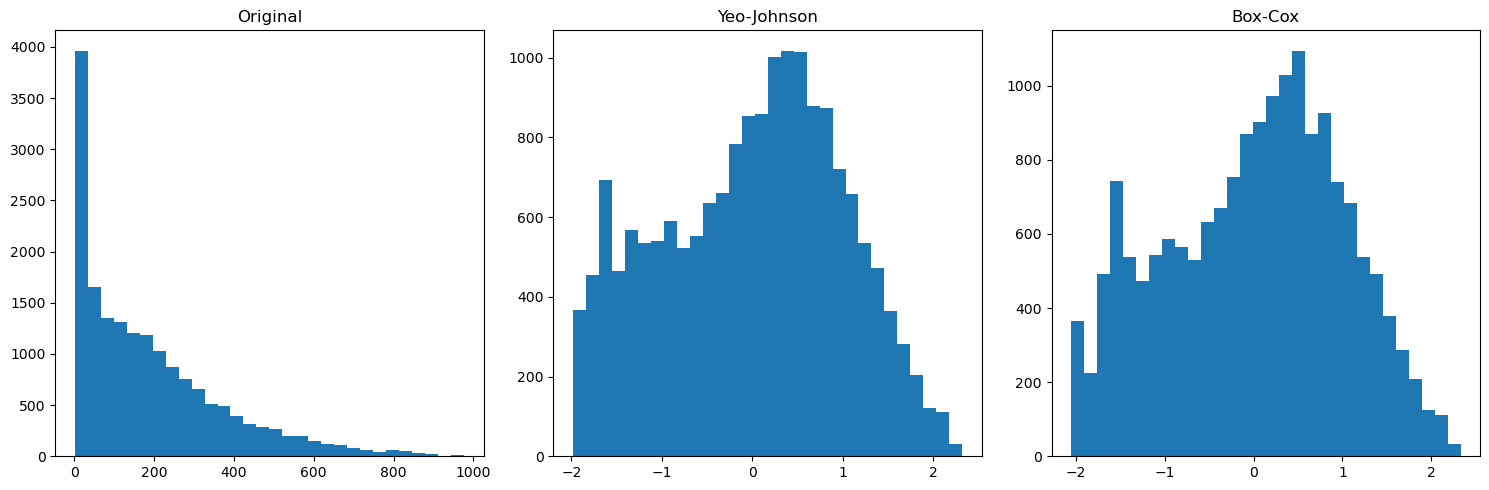

In [34]:
fig, ax = plt.subplots(1,3, figsize=(15,5))

ax[0].hist(df2["cnt"], bins=30)
ax[0].set_title("Original")

ax[1].hist(df2["cnt_pt"], bins=30)
ax[1].set_title("Yeo-Johnson")

ax[2].hist(df2["cnt_bc"], bins=30)
ax[2].set_title("Box-Cox")

plt.tight_layout()
plt.show()

In [35]:
comparison = pd.DataFrame({
    "Method": ["Original", "Yeo-Johnson", "Box-Cox"],
    "Skewness": [
        df2["cnt"].skew(),
        df2["cnt_pt"].skew(),
        df2["cnt_bc"].skew()
    ]
})

comparison

,Method,Skewness
0,Original,1.277412
1,Yeo-Johnson,-0.137397
2,Box-Cox,-0.147928


In [36]:
import os

print(os.getcwd())

C:\Users\Raksha\anaconda_projects\02c72f75-e472-4303-8fbb-0a309f1aabf2


In [37]:
import os
print(os.listdir())

['.ipynb_checkpoints', 'fetch_california_housing.csv', 'hour.csv', 'Transformer.ipynb']


In [38]:
import os

for file in os.listdir():
    print(file)

.ipynb_checkpoints
fetch_california_housing.csv
hour.csv
Transformer.ipynb
